# `schwingerModel` spectroscopy pipeline

This notebook walks the full analysis chain:

**interpolator** (build states from quantum numbers) → **wick** (contract into diagram tables) → **evaluator** (numeric traces on distillation data) → **GEVP** (ensemble statistics and masses)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
from tqdm import tqdm

from joblib import Parallel, delayed

import pickle

import schwingerModel as sim

from schwingerModel.interpolator import MesonOp, mesonMultiplet, makeState

## Building operators

States are built from `MesonOp`s — a gamma structure, a covariant-derivative count, and a momentum. They contain no flavor information, because flavor is not relevant to the actual traces that are taken (it only decides which contractions exist).

In [3]:
g5 = MesonOp(gamma="g5",DNum=0,momk=0)
print(g5)

MesonOp(gamma='g5', DNum=0, momk=0)


We can create a state using these `MesonOp`s by first generating the associated isospin multiplet.

In [4]:
iso0 = mesonMultiplet(g5,I=0)
iso1 = mesonMultiplet(g5,I=1)

The different $I_z$ components of the multiplet are accessed by indexing.

In [5]:
print("Triplet:")
for i in range(-1,2):
    print(f"I_z={i}: ", iso1[i])

print("Singlet:")
print(iso0[0])

Triplet:
I_z=-1:  (+1+0j)[u_bar g5 d]
I_z=0:  (-0.7071+0j)[d_bar g5 d]  (+0.7071+0j)[u_bar g5 u]
I_z=1:  (-1+0j)[d_bar g5 u]
Singlet:
(-0.7071+0j)[d_bar g5 d]  (-0.7071+0j)[u_bar g5 u]


Product states are made with `makeState`. For two identical pions at rest only $I=0$ and $I=2$ survive: the $I=1$ coupling of two isotriplets is antisymmetric under exchange, so it cancels for indistinguishable constituents (Bose symmetry).

In [8]:
print("pipi states")

for I in range(3):
    print(I)
    for Iz in range(-I,I+1):
        print(f"Iz:{Iz}", makeState(content=[(MesonOp("g5"),1),(MesonOp("g5"),1)],I=I,I3=Iz,momTotal=0))

pipi states
0
Iz:0 (-0.2887+0j)[d_bar g5 d · d_bar g5 d]  (+0.5774+0j)[d_bar g5 d · u_bar g5 u]  (-1.155+0j)[d_bar g5 u · u_bar g5 d]  (-0.2887+0j)[u_bar g5 u · u_bar g5 u]
1
Iz:-1 Interpolator(0)
Iz:0 Interpolator(0)
Iz:1 Interpolator(0)
2
Iz:-2 (+1+0j)[u_bar g5 d · u_bar g5 d]
Iz:-1 (-1+0j)[d_bar g5 d · u_bar g5 d]  (+1+0j)[u_bar g5 d · u_bar g5 u]
Iz:0 (+0.4082+0j)[d_bar g5 d · d_bar g5 d]  (-0.8165+0j)[d_bar g5 d · u_bar g5 u]  (-0.8165+0j)[d_bar g5 u · u_bar g5 d]  (+0.4082+0j)[u_bar g5 u · u_bar g5 u]
Iz:1 (+1+0j)[d_bar g5 d · d_bar g5 u]  (-1+0j)[d_bar g5 u · u_bar g5 u]
Iz:2 (+1+0j)[d_bar g5 u · d_bar g5 u]


The same content with back-to-back momenta ($k=\pm 1$) makes the two pions distinguishable, so the antisymmetric $I=1$ ($\rho$-channel) combination now survives.

In [10]:
print("piDpi states")

for I in range(3):
    print(I)
    for Iz in range(-I,I+1):
        print(f"Iz:{Iz}", makeState(content=[(MesonOp("g5",momk=1),1),(MesonOp("g5",momk=-1),1)],I=I,I3=Iz,momTotal=0))

piDpi states
0
Iz:0 (-0.2887+0j)[d_bar g5,k=-1 d · d_bar g5,k=+1 d]  (+0.2887+0j)[d_bar g5,k=-1 d · u_bar g5,k=+1 u]  (+0.2887+0j)[d_bar g5,k=+1 d · u_bar g5,k=-1 u]  (-0.5774+0j)[d_bar g5,k=-1 u · u_bar g5,k=+1 d]  (-0.5774+0j)[d_bar g5,k=+1 u · u_bar g5,k=-1 d]  (-0.2887+0j)[u_bar g5,k=-1 u · u_bar g5,k=+1 u]
1
Iz:-1 (+0.5+0j)[d_bar g5,k=-1 d · u_bar g5,k=+1 d]  (-0.5+0j)[d_bar g5,k=+1 d · u_bar g5,k=-1 d]  (+0.5+0j)[u_bar g5,k=-1 d · u_bar g5,k=+1 u]  (-0.5+0j)[u_bar g5,k=+1 d · u_bar g5,k=-1 u]
Iz:0 (+0.7071+0j)[d_bar g5,k=-1 u · u_bar g5,k=+1 d]  (-0.7071+0j)[d_bar g5,k=+1 u · u_bar g5,k=-1 d]
Iz:1 (+0.5+0j)[d_bar g5,k=-1 d · d_bar g5,k=+1 u]  (-0.5+0j)[d_bar g5,k=+1 d · d_bar g5,k=-1 u]  (+0.5+0j)[d_bar g5,k=-1 u · u_bar g5,k=+1 u]  (-0.5+0j)[d_bar g5,k=+1 u · u_bar g5,k=-1 u]
2
Iz:-2 (+1+0j)[u_bar g5,k=-1 d · u_bar g5,k=+1 d]
Iz:-1 (-0.5+0j)[d_bar g5,k=-1 d · u_bar g5,k=+1 d]  (-0.5+0j)[d_bar g5,k=+1 d · u_bar g5,k=-1 d]  (+0.5+0j)[u_bar g5,k=-1 d · u_bar g5,k=+1 u]  (+0.5+0j)[u

## Wick contraction

`contract` returns the weights of all the applicable ways of connecting the vertices of the graph — a table mapping each diagram (a product of traces) to its coefficient, with the fermion-loop sign already included. `formatTable` is a nice way to visualize the traces that will be done.

In [21]:
table = sim.wick.contract(snkOp=iso1[0],srcOp=iso1[0])
print(sim.wick.formatTable(table))

+0.5+0j  Tr[ snk:g5 --d--> ]  x  Tr[ src:g5~ --d--> ]
-0.5+0j  Tr[ snk:g5 --d--> ]  x  Tr[ src:g5~ --u--> ]
-0.5+0j  Tr[ snk:g5 --d--> src:g5~ --d--> ]
-0.5+0j  Tr[ snk:g5 --u--> ]  x  Tr[ src:g5~ --d--> ]
+0.5+0j  Tr[ snk:g5 --u--> ]  x  Tr[ src:g5~ --u--> ]
-0.5+0j  Tr[ snk:g5 --u--> src:g5~ --u--> ]


Once we have this form we don't care about flavors anymore because of isospin symmetry: `mergeFlavors` maps the $u$ and $d$ propagator edges to one degenerate class `q`, letting isospin cancellations drop out symbolically.

In [22]:
table = sim.wick.mergeFlavors(table)
sim.wick.formatTable(table)

'-1+0j  Tr[ snk:g5 --q--> src:g5~ --q--> ]'

## Evaluating on gauge configurations

`readDistillMeta` loads the metadata about the lattice configs that will be analyzed (dimensions, $\beta$, quark mass, stored elemental keys, available config indices) without loading any bulk data.

In [37]:
path = "./configs/400kSteps_scale_0.5.hdf5"
meta = sim.distillation.readDistillMeta(path)

To do the analysis manually, load the distillation data for one config. It is stored in an HDF5 file; `DistillWorkspace.load` rebuilds the per-config workspace (eigenvectors, perambulator, elementals).

In [27]:
ws = sim.distillation.DistillWorkspace.load(path,configIndex=0)

This is what is inside one of these workspaces:

In [35]:
for name, val in vars(ws).items():
    if isinstance(val, np.ndarray):
        print(f"{name:12s} {val.shape} {val.dtype}")
    elif isinstance(val, dict):
        print(f"{name:12s} keys: {sorted(val)}")
    else:
        print(f"{name:12s} {type(val).__name__}")

modelObj     SimpleNamespace
configIndex  int
chemicalPot  int
eigVecs      (16, 8, 5) complex128
_tau         (16, 16, 5, 2, 5, 2) complex128
_elem        keys: [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2)]


We can now evaluate the traces we found using this workspace. `evalTable` returns `EvalResult(conn, disc)`: the translation-averaged connected correlator, plus unevaluated loop factors for fully disconnected diagrams (those need ensemble-level vacuum subtraction, so they are not combined here).

In [38]:
res = sim.evaluator.evalTable(ws, table)     # EvalResult(conn, disc)

The $\pi$ correlator on a single configuration:

Text(0.5, 1.0, '$\\pi$ Correlation for config. 0')

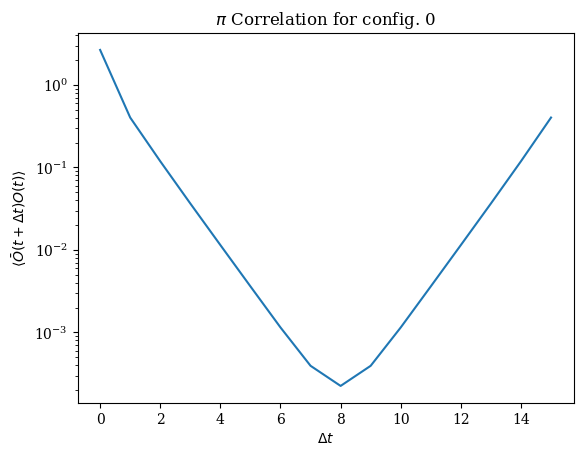

In [49]:
plt.semilogy(np.real(res.conn))
plt.xlabel(r"$\Delta t$")
plt.ylabel(r"$\langle \bar{O}(t+\Delta t) O(t)\rangle$")
plt.title(r"$\pi$ Correlation for config. 0")

## Measuring an ensemble

Instead of doing this by hand for each config, `measureEnsemble` does it automatically, in parallel, over the configs listed in `meta.configIndices`. We also add a second operator ($\gamma_5 D^2$) to the basis, so we get a $2\times 2$ correlation matrix at each time separation.

In [60]:
g5 = iso1[0]
g5D2 = mesonMultiplet(MesonOp("g5",DNum=2),I=1)[0]
ensembleCorrelators = sim.GEVP.measureEnsemble(filePath=path, configIndices=(meta.configIndices)[::20],basis=[g5,g5D2])

Measuring configs:   0%|          | 0/4000 [00:00<?, ?it/s]

## Three ways to analyze the data

All three use bootstrapping; they differ only in the `reduce` applied to each resample's mean correlation matrix.

### 1. No reduction

Just average the $2\times 2$ matrices at each time — raw correlator statistics.

In [61]:
bootstrappedCorrels = sim.GEVP.bootstrapEnsemble(ensembleCorrelators,progress=False)

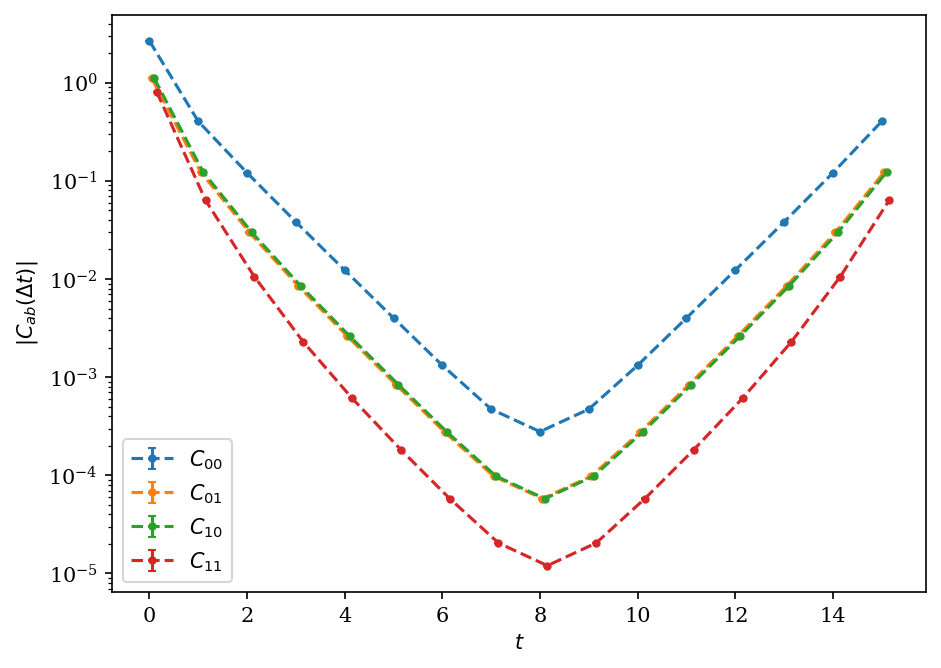

In [73]:
central, err, _ = bootstrappedCorrels
n, T = central.shape[0], central.shape[-1]
ts = np.arange(T)

fig, ax = plt.subplots(figsize=(7, 5),dpi=150)
for a in range(n):
    for b in range(n):
        ax.errorbar(ts + 0.05 * (a * n + b),   # tiny x-offset so points don't overlap
                    np.abs(central[a, b]),
                    yerr=err[[1, 0], a, b, :],
                    fmt="o--", ms=3, capsize=2, label=f"$C_{{{a}{b}}}$")

ax.set_yscale("log")
ax.set_xlabel("$t$")
ax.set_ylabel(r"$|C_{ab}(\Delta t)|$")
ax.legend()

### 2. GEVP reduction

`makeGevpReduce` is a wrapper on top of `sim.GEVP.gevpReduce`: it fixes the reference eigenvectors on the first (central) call so that states are labeled consistently across bootstrap draws. `gevpTi` is the reference point for the GEVP normalization $\lambda(t_i)=1$ — it is helpful if this is not zero.

In [74]:
gevpTi = 1
bootstrappedGEVP = sim.GEVP.bootstrapEnsemble(ensembleCorrelators,reduce=sim.GEVP.makeGevpReduce(ti=gevpTi),progress=False)

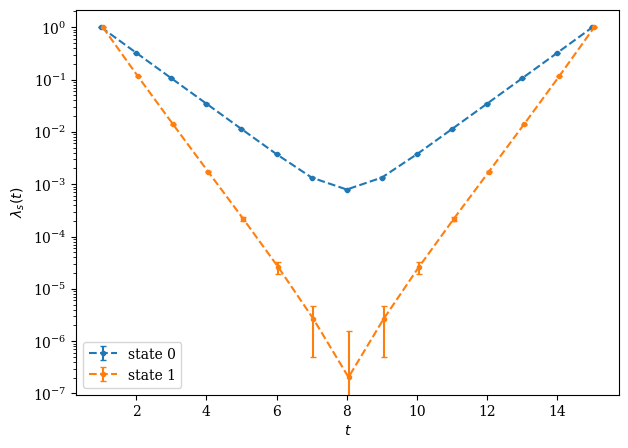

In [77]:
central, err, _ = bootstrappedGEVP
nT, nStates = central.shape
ts = gevpTi + np.arange(nT)          # curve index k  <->  physical time t = ti + k

fig, ax = plt.subplots(figsize=(7, 5))
for s in range(nStates):
    ax.errorbar(ts + 0.05 * s, central[:, s],
                yerr=err[[1, 0], :, s],          # matplotlib wants (lower, upper)
                fmt="o--", ms=3, capsize=2, label=f"state {s}")

ax.set_yscale("log")
ax.set_xlabel("$t$")
ax.set_ylabel(r"$\lambda_s(t)$")
ax.legend()


### 3. Mass extraction

The third reduction fits exponentials to the GEVP curves to extract the masses of the states. The fit is redone inside every bootstrap resample, which gives the best error bars: the mass distribution exactly marginalizes the amplitude and inherits all data correlations (including the mass–mass covariance).

In [78]:
bootstrappedMasses = sim.GEVP.bootstrapEnsemble(ensembleCorrelators,reduce=sim.GEVP.massReduce(ti=gevpTi,fitT=(2,6),withAmp=True),progress=False)

With `withAmp=True` the central value is `(nStates, 2)` with columns `[E, logA]`; extracting the masses and their uncertainties:

In [96]:
masses = bootstrappedMasses[0][:, 0]
massesErr = bootstrappedMasses[1][:, :, 0].mean(axis=0) 
for i in range(2):
    print(f"Mass of state {i}: {masses[i]:.3f} +/- {massesErr[i]:.3f}")

Mass of state 0: 1.115 +/- 0.002
Mass of state 1: 2.095 +/- 0.078


Finally, compare the extracted masses with the GEVP curves. The solid line spans the fit window (shaded band); dotted is the extrapolation outside it. The fitted curve need not pass through the normalization point $\lambda(t_i)=1$ — the free amplitude measures excited-state contamination at $t_i$.

(1e-08, 2)

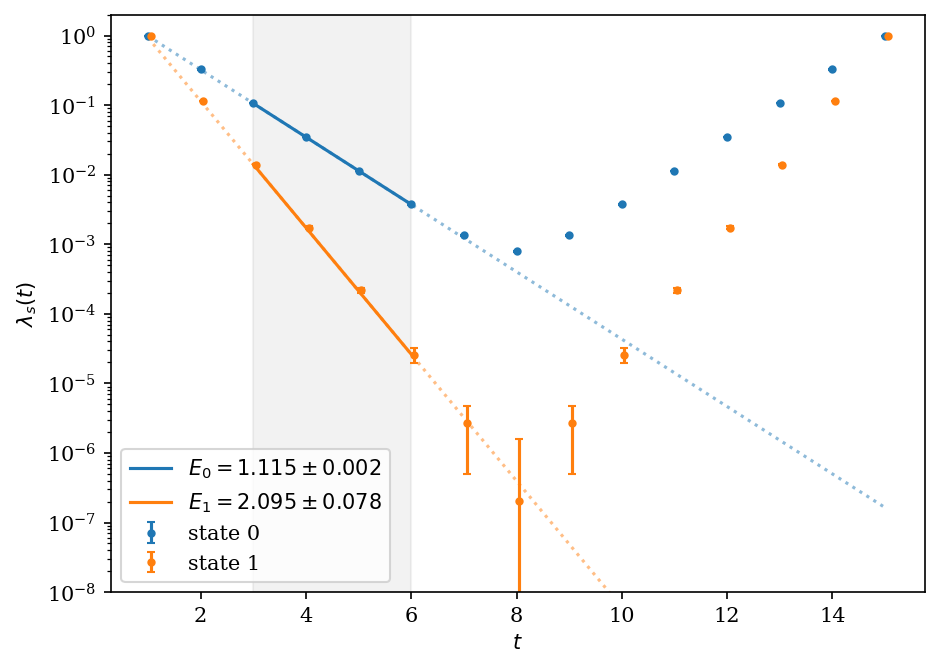

In [101]:
central, err, _ = bootstrappedGEVP
nT, nStates = central.shape
ts = gevpTi + np.arange(nT)          # curve index k  <->  physical time t = ti + k

fitT = (2, 6)                        # match the massReduce window

fig, ax = plt.subplots(figsize=(7, 5),dpi=150)
for s in range(nStates):
    pts = ax.errorbar(ts + 0.05 * s, central[:, s],
                      yerr=err[[1, 0], :, s],
                      fmt="o", ms=3, capsize=2, label=f"state {s}")

    # fitted exponential: curves live in curve-index units k = t - gevpTi
    E, logA = bootstrappedMasses[0][s]
    kFit = np.linspace(fitT[0], fitT[1] - 1, 50)
    ax.plot(gevpTi + kFit, np.exp(logA - E * kFit),
            "-", color=pts[0].get_color(),
            label=rf"$E_{s}={E:.3f} \pm {massesErr[s]:.3f}$")
    # dotted continuation outside the fit window
    kAll = np.linspace(0, nT - 1, 100)
    ax.plot(gevpTi + kAll, np.exp(logA - E * kAll),
            ":", color=pts[0].get_color(), alpha=0.5)

ax.axvspan(gevpTi + fitT[0], gevpTi + fitT[1] - 1, color="gray", alpha=0.1)

ax.set_yscale("log")
ax.set_xlabel("$t$")
ax.set_ylabel(r"$\lambda_s(t)$")
ax.legend()
ax.set_ylim([1e-8,2])
